In [ ]:
!pip install -q openai langchain_openai langchain_core

In [ ]:
print("=== Logo Generator ===")

company_name = input("Company name: ")
industry = input("Industry / business field: ")
target_audience = input("Target audience: ")

preferred_style = input(
    "Preferred style or color palette (optional, press Enter to skip): "
)

preferred_symbol = input(
    "Preferred symbol or element (optional, press Enter to skip): "
)

print("\n--- Company Information ---")
print("Company Name:", company_name)
print("Industry:", industry)
print("Target Audience:", target_audience)
print("Style / Colors:", preferred_style or "Not specified")
print("Symbol / Element:", preferred_symbol or "Not specified")

=== Logo Generator ===
Company name: لونا
Industry / business field: مبلمان اداری
Target audience: سازمانها و شرکت های بزرگ
Preferred style or color palette (optional, press Enter to skip): قرمز 
Preferred symbol or element (optional, press Enter to skip): صندلی و میز

--- Company Information ---
Company Name: لونا
Industry: مبلمان اداری
Target Audience: سازمانها و شرکت های بزرگ
Style / Colors: قرمز 
Symbol / Element: صندلی و میز


In [ ]:
from IPython.core.display import Image
from google.colab import userdata
from langchain_openai import ChatOpenAI
import base64
from openai import OpenAI
from langchain_core.prompts import PromptTemplate


prompt_template=PromptTemplate.from_template("""
You are a professional logo designer.

Based on the following company information, create ONE detailed
image-generation prompt for designing the company's logo.

Company information:

Company name: {company_name}
Industry: {industry}
Target audience: {target_audience}
Preferred style/colors: {preferred_style}
Preferred symbol: {preferred_symbol}

Requirements:
- Professional brand identity
- Include the company name
- Consider the industry and target audience
- Respect requested colors and style
- Use the requested symbol when provided
- Clean, modern and scalable design
- Avoid unnecessary complexity
- Return ONLY the final image-generation prompt
- Image must be a logo
- Use symbols inspired by Iran and Tehran where appropriate
- Design for a square 200x200 px logo
""")




def generate_prompt(prompt):
    client = ChatOpenAI(
        model="openrouter/free",
        base_url="https://openrouter.ai/api/v1",
        api_key=api_key
    )

    response = client.invoke(instruction)

    return response.content



def createImage(prompt):
    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=api_key
    )

    generation_response = client.images.generate(
        model="bytedance-seed/seedream-4.5",
        prompt=prompt,
        n=1
    )

    return generation_response.data[0].b64_json



def save_and_display_image(image_base64, filename="logo.png"):
    # Decode Base64
    image_bytes = base64.b64decode(image_base64)

    # Save image
    with open(filename, "wb") as f:
        f.write(image_bytes)

    # Display in Colab
    display(Image(filename=filename))

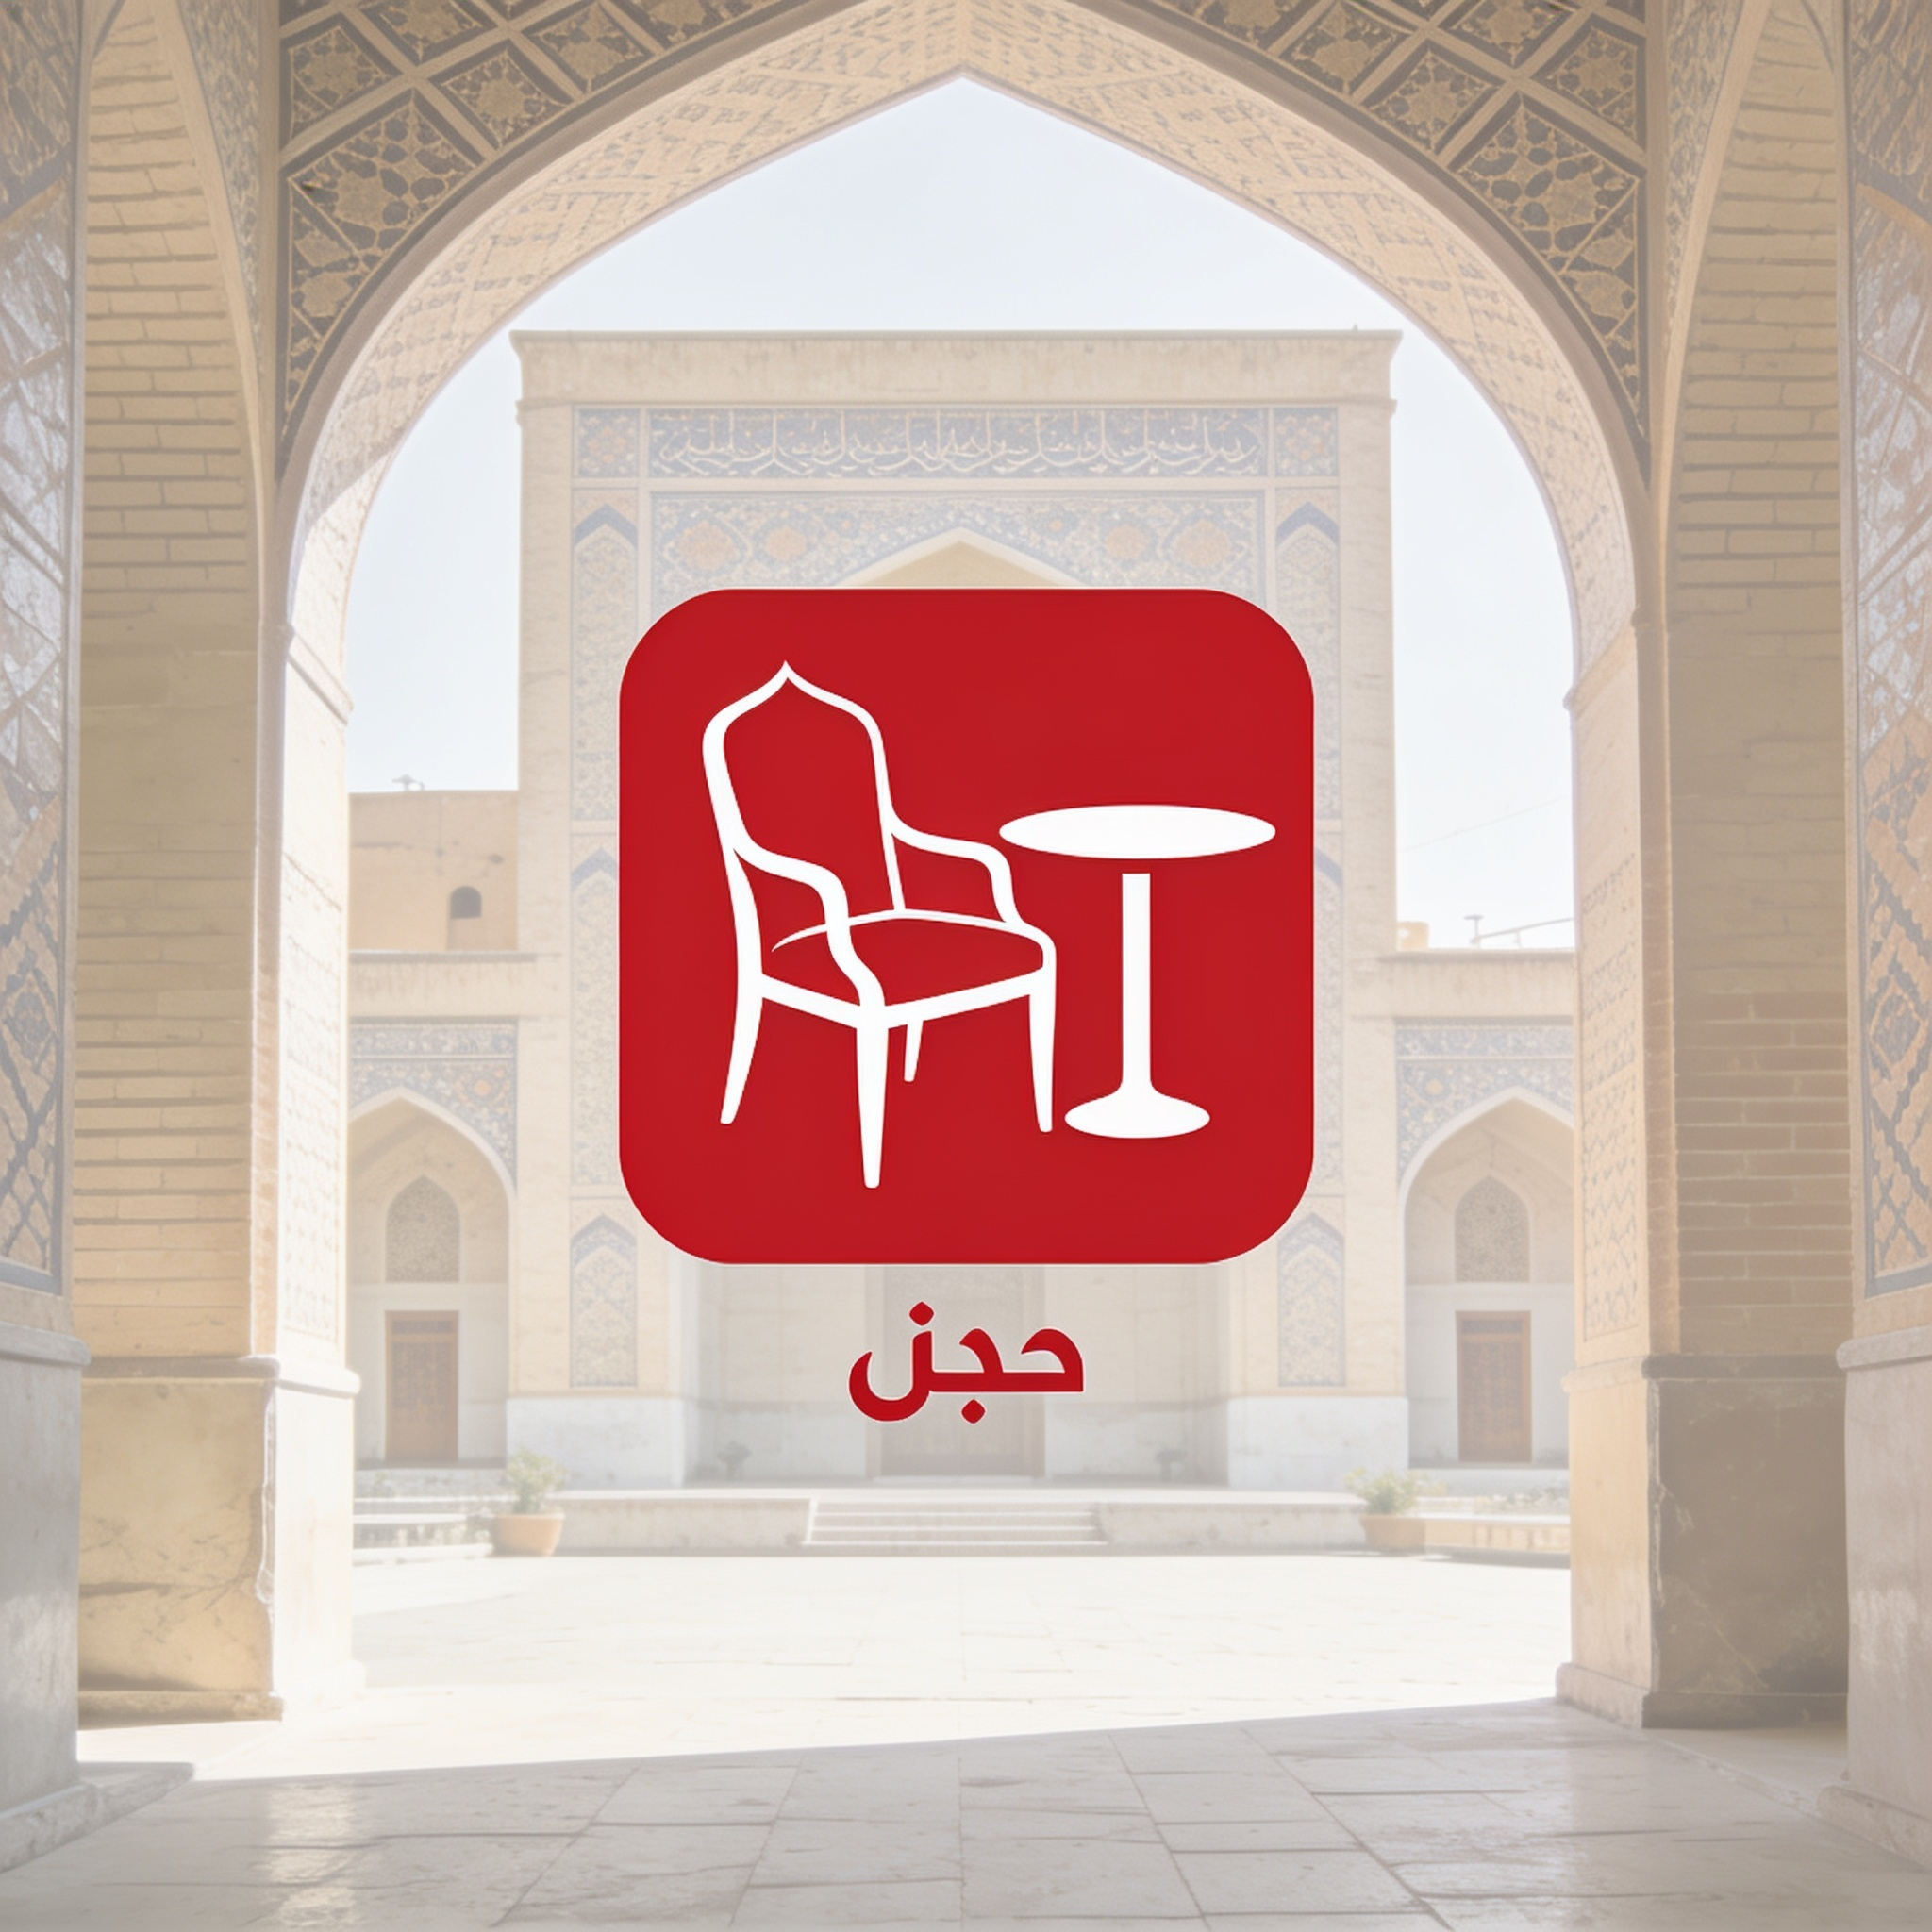

In [ ]:
from langchain_core.runnables import RunnableLambda
prompt = prompt_template.format(
        company_name=company_name,
        industry=industry,
        target_audience=target_audience,
        preferred_style=preferred_style or "Not specified",
        preferred_symbol=preferred_symbol or "Not specified"
    )


chain = (
    prompt_template
    | RunnableLambda(generate_prompt)
    | RunnableLambda(createImage)
    | RunnableLambda(save_and_display_image)
)

chain.invoke({
    "company_name": company_name,
    "industry": industry,
    "target_audience": target_audience,
    "preferred_style": preferred_style or "Not specified",
    "preferred_symbol": preferred_symbol or "Not specified"
})